## Training

The purpose of this note book is to setup training for the ED Fast Track model

In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import pickle
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR, OneCycleLR

In [32]:
class MultiInputFNN(nn.Module):
    def __init__(self, 
                 diagnosis_emb_dim=768, 
                 medication_emb_dim=768, 
                 pmh_emb_dim=768,
                 emb_dense_dim=50,
                 raw_features_dim=100,  # Set based on your feature count
                 hidden_dims=[50, 50, 50, 2]):
        super(MultiInputFNN, self).__init__()
        
        # Process diagnosis embeddings
        self.diagnosis_dense = nn.Linear(diagnosis_emb_dim, emb_dense_dim)
        self.diagnosis_batch_norm = nn.BatchNorm1d(emb_dense_dim)
        
        # Process medication embeddings
        self.medication_dense = nn.Linear(medication_emb_dim, emb_dense_dim)
        self.medication_batch_norm = nn.BatchNorm1d(emb_dense_dim)
        
        # Process PMH embeddings
        self.pmh_dense = nn.Linear(pmh_emb_dim, emb_dense_dim)
        self.pmh_batch_norm = nn.BatchNorm1d(emb_dense_dim)
        
        # Combined input dimension for first dense layer after concatenation
        combined_emb_dim = emb_dense_dim * 3
        self.combined_input_dim = combined_emb_dim + raw_features_dim
        
        # Main network path
        self.dense1 = nn.Linear(self.combined_input_dim, hidden_dims[0])
        self.dense2 = nn.Linear(hidden_dims[0], hidden_dims[1])
        self.dense3 = nn.Linear(hidden_dims[1], hidden_dims[2])
        self.output = nn.Linear(hidden_dims[2], hidden_dims[3])
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
    
    def forward(self, diagnosis_emb, medication_emb, pmh_emb, raw_features):
        # Process each embedding type
        x_diag = self.diagnosis_batch_norm(self.relu(self.diagnosis_dense(diagnosis_emb)))
        x_med = self.medication_batch_norm(self.relu(self.medication_dense(medication_emb)))
        x_pmh = self.pmh_batch_norm(self.relu(self.pmh_dense(pmh_emb)))
        
        # Concatenate embeddings with raw features
        x_combined = torch.cat([x_diag, x_med, x_pmh, raw_features], dim=1)
        
        # Forward pass through main network
        x = self.relu(self.dense1(x_combined))
        x = self.dropout(self.relu(self.dense2(x)))
        x = self.relu(self.dense3(x))
        x = self.output(x)
        
        return x

In [33]:
class MultiInputDataset(Dataset):
    def __init__(self, diagnosis_embeddings, medication_embeddings, pmh_embeddings, features, labels=None):
        """
        Args:
            diagnosis_embeddings: Dictionary mapping CSN to diagnosis embeddings
            medication_embeddings: Dictionary mapping CSN to medication embeddings
            pmh_embeddings: Dictionary mapping CSN to PMH embeddings
            features: DataFrame or array of features
            labels: Target labels
        """
        # Get CSNs from the features DataFrame
        self.csns = features.index.tolist() if isinstance(features, pd.DataFrame) else list(range(len(features)))
        self.features = features.values if isinstance(features, pd.DataFrame) else features
        
        # Store embeddings dictionaries
        self.diagnosis_embeddings = diagnosis_embeddings
        self.medication_embeddings = medication_embeddings
        self.pmh_embeddings = pmh_embeddings
        
        # Check if we have labels
        self.labels = labels.values if isinstance(labels, pd.DataFrame) else labels
        
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        # Get the CSN for this index
        csn = self.csns[idx]
        
        # Get embeddings for this CSN
        diagnosis_emb = torch.FloatTensor(self.diagnosis_embeddings[csn])
        medication_emb = torch.FloatTensor(self.medication_embeddings[csn])
        pmh_emb = torch.FloatTensor(self.pmh_embeddings[csn])
        
        # Get features
        feature = torch.FloatTensor(self.features[idx])
        
        if self.labels is not None:
            label = torch.LongTensor([self.labels[idx]]).squeeze() 
            return diagnosis_emb, medication_emb, pmh_emb, feature, label
        else:
            return diagnosis_emb, medication_emb, pmh_emb, feature

In [34]:
# Function to load data for a single split (train or validation)
def load_split_data(diag_emb_path, med_emb_path, pmh_emb_path, features_path, targets_path):
    # Load embeddings from pickle files
    with open(diag_emb_path, 'rb') as f:
        diagnosis_embeddings = pickle.load(f)
    
    with open(med_emb_path, 'rb') as f:
        medication_embeddings = pickle.load(f)
    
    with open(pmh_emb_path, 'rb') as f:
        pmh_embeddings = pickle.load(f)
    
    # Load features and targets from CSV
    features_df = pd.read_csv(features_path, index_col='CSN')  # Assuming CSN is in the features CSV
    targets_df = pd.read_csv(targets_path, index_col='CSN')  # Assuming CSN is in the targets CSV
    
    # Convert targets to numpy arrays
    targets = targets_df.values.flatten()
    
    return diagnosis_embeddings, medication_embeddings, pmh_embeddings, features_df, targets


In [35]:
def get_scheduler(scheduler_name, optimizer, **kwargs):
    if scheduler_name == 'plateau':
        return ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=10, **kwargs)
    elif scheduler_name == 'cosine':
        return CosineAnnealingLR(optimizer, T_max=100, **kwargs)
    elif scheduler_name == 'onecycle':
        return OneCycleLR(optimizer, max_lr=0.01, total_steps=100, **kwargs)
    else:
        return None

In [36]:
def train_model(model, train_loader, val_loader, criterion, optimizer, bert_variant, scheduler=None, scheduler_name='plateau', num_epochs=10, device='cpu'):
    model = model.to(device)
    best_val_loss = float('inf')
    best_val_auc = 0.0
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        
        for diagnosis_emb, medication_emb, pmh_emb, features, labels in train_loader:
            # print(f"Diagnosis Embedding Shape: {diagnosis_emb.shape}")
            # print(f"Medication Embedding Shape: {medication_emb.shape}")
            # print(f"PMH Embedding Shape: {pmh_emb.shape}")
            # print(f"Features Shape: {features.shape}")
            # print(f"Labels Shape: {labels.shape}")

            # Move data to device
            diagnosis_emb = diagnosis_emb.to(device)
            medication_emb = medication_emb.to(device)
            pmh_emb = pmh_emb.to(device)
            features = features.to(device)
            labels = labels.to(device)
            
            # Zero gradients
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(diagnosis_emb, medication_emb, pmh_emb, features)
            loss = criterion(outputs, labels)
            
            
            # Backward pass and optimize
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        all_labels = []
        all_probs = []
        
        with torch.no_grad():
            for diagnosis_emb, medication_emb, pmh_emb, features, labels in val_loader:
                diagnosis_emb = diagnosis_emb.to(device)
                medication_emb = medication_emb.to(device)
                pmh_emb = pmh_emb.to(device)
                features = features.to(device)
                labels = labels.to(device)
                
                outputs = model(diagnosis_emb, medication_emb, pmh_emb, features)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                
                # Get probabilities
                # For binary classification
                probs = torch.softmax(outputs, dim=1)[:, 1] if outputs.shape[1] == 2 else torch.sigmoid(outputs)
                
                # Store for AUC calculation
                all_labels.append(labels.cpu().numpy())
                all_probs.append(probs.cpu().numpy())
        
        # Calculate average losses
        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        
        # Calculate AUC ROC
        all_labels = np.concatenate(all_labels)
        all_probs = np.concatenate(all_probs)
        
        # For binary classification
        val_auc = roc_auc_score(all_labels, all_probs)
        val_ap = average_precision_score(all_labels, all_probs)
        
        # Update scheduler
        if scheduler is not None:
            if scheduler_name == 'plateau':
                scheduler.step(val_loss)
            else:
                scheduler.step()
        
        # Save best model - could save based on loss or AUC
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), f'best_model_{bert_variant}_loss.pt')
            
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            torch.save(model.state_dict(), f'best_model_{bert_variant}_auc.pt')
        
        print(f'Epoch {epoch+1}/{num_epochs}, '
            f'Train Loss: {train_loss:.4f}, '
            f'Val Loss: {val_loss:.4f}, '
            f'Val AUC: {val_auc:.4f}, '
            f'Val AP: {val_ap:.4f}, '
            f'LR: {optimizer.param_groups[0]["lr"]:.6f}')
    
    return model

In [37]:
# Main execution code - with fixes
# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

BERT_LIST = [
    'bert_base',
    'bio_clinical_bert',
    'blue_bert',
    'pubmed_bert'
]

SPLIT_TYPE = 'random'
BERT = BERT_LIST[3]

# Training data paths
train_diag_emb_path = f'data/embeddings/visit_diagnosis_{SPLIT_TYPE}_train_{BERT}.pkl'
train_med_emb_path = f'data/embeddings/meds_{SPLIT_TYPE}_train_{BERT}.pkl'
train_pmh_emb_path = f'data/embeddings/pmh_{SPLIT_TYPE}_train_{BERT}.pkl'
train_features_path = f'data/features_all_{SPLIT_TYPE}_train.csv'
train_targets_path = f'data/features_target_{SPLIT_TYPE}_train.csv'

# Validation data paths
val_diag_emb_path = f'data/embeddings/visit_diagnosis_{SPLIT_TYPE}_val_{BERT}.pkl'
val_med_emb_path = f'data/embeddings/meds_{SPLIT_TYPE}_val_{BERT}.pkl'
val_pmh_emb_path = f'data/embeddings/pmh_{SPLIT_TYPE}_val_{BERT}.pkl'
val_features_path = f'data/features_all_{SPLIT_TYPE}_val.csv'
val_targets_path = f'data/features_target_{SPLIT_TYPE}_val.csv'

# Load training data
train_diagnosis_embeddings, train_medication_embeddings, train_pmh_embeddings, train_features, train_targets = load_split_data(
    train_diag_emb_path, train_med_emb_path, train_pmh_emb_path, train_features_path, train_targets_path
)

# Load validation data
val_diagnosis_embeddings, val_medication_embeddings, val_pmh_embeddings, val_features, val_targets = load_split_data(
    val_diag_emb_path, val_med_emb_path, val_pmh_emb_path, val_features_path, val_targets_path
)

# Scale features - fit on training data, transform both train and validation
# scaler = StandardScaler()
# train_features_scaled = scaler.fit_transform(train_features)
# val_features_scaled = scaler.transform(val_features)

# Create datasets - adjusted for dictionary embeddings
train_dataset = MultiInputDataset(
    train_diagnosis_embeddings, 
    train_medication_embeddings, 
    train_pmh_embeddings, 
    train_features,
    train_targets
)

val_dataset = MultiInputDataset(
    val_diagnosis_embeddings, 
    val_medication_embeddings, 
    val_pmh_embeddings, 
    val_features,
    val_targets
)

# Create data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

# Get embedding dimensions from the first entry in each dictionary
# Fix for the error: 'dict' object has no attribute 'shape'
first_diag_key = next(iter(train_diagnosis_embeddings))
first_med_key = next(iter(train_medication_embeddings))
first_pmh_key = next(iter(train_pmh_embeddings))

diagnosis_emb_dim = len(train_diagnosis_embeddings[first_diag_key])
medication_emb_dim = len(train_medication_embeddings[first_med_key])
pmh_emb_dim = len(train_pmh_embeddings[first_pmh_key])

# Initialize model with correct dimensions
raw_features_dim = train_features.shape[1]
model = MultiInputFNN(
    diagnosis_emb_dim=diagnosis_emb_dim,
    medication_emb_dim=medication_emb_dim,
    pmh_emb_dim=pmh_emb_dim,
    raw_features_dim=raw_features_dim,
    emb_dense_dim=50,
    #hidden_dims=[50, 50, 50, 2]
    hidden_dims=[64, 128, 64, 2]  # Adjust based on your output dimension
)

# Loss function and optimizer
# Calculate class distribution
class_counts = np.bincount(train_targets)
total_samples = len(train_targets)
class_weights = torch.tensor([total_samples/count for count in class_counts], dtype=torch.float).to(device)
print(f"Class counts: {class_counts}")
print(f"Class weights: {class_weights}")

# Update the loss function
criterion = nn.CrossEntropyLoss(weight=class_weights)
#criterion = nn.CrossEntropyLoss()  # Change based on your task (MSE for regression, CrossEntropy for classification)
optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=1e-5)

# LR Scheduler - choose one
scheduler_name = 'cosine'  # 'plateau', 'cosine', or 'onecycle'
scheduler = get_scheduler(
    scheduler_name, 
    optimizer,
)

# Train model
trained_model = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    bert_variant=BERT,
    scheduler=scheduler,
    scheduler_name=scheduler_name,
    num_epochs=13,
    device=device,
)

print("Training complete!")

Using device: cpu
Class counts: [7967 2632]
Class weights: tensor([1.3304, 4.0270])
Epoch 1/13, Train Loss: 0.6412, Val Loss: 0.5695, Val AUC: 0.7770, Val AP: 0.5686, LR: 0.000100
Epoch 2/13, Train Loss: 0.5656, Val Loss: 0.5435, Val AUC: 0.7986, Val AP: 0.6039, LR: 0.000100
Epoch 3/13, Train Loss: 0.5478, Val Loss: 0.5327, Val AUC: 0.8079, Val AP: 0.6245, LR: 0.000100
Epoch 4/13, Train Loss: 0.5385, Val Loss: 0.5341, Val AUC: 0.8137, Val AP: 0.6319, LR: 0.000100
Epoch 5/13, Train Loss: 0.5319, Val Loss: 0.5266, Val AUC: 0.8134, Val AP: 0.6307, LR: 0.000099
Epoch 6/13, Train Loss: 0.5270, Val Loss: 0.5224, Val AUC: 0.8182, Val AP: 0.6380, LR: 0.000099
Epoch 7/13, Train Loss: 0.5196, Val Loss: 0.5244, Val AUC: 0.8178, Val AP: 0.6372, LR: 0.000099
Epoch 8/13, Train Loss: 0.5186, Val Loss: 0.5350, Val AUC: 0.8117, Val AP: 0.6174, LR: 0.000098
Epoch 9/13, Train Loss: 0.5167, Val Loss: 0.5260, Val AUC: 0.8163, Val AP: 0.6322, LR: 0.000098
Epoch 10/13, Train Loss: 0.5104, Val Loss: 0.5223, V


Evaluating BERT Base...
BERT Base:
  Test Loss: 0.5138, Test AUC: 0.8132
  Accuracy: 0.7609, Precision: 0.5205, Recall: 0.7275, F1: 0.6068

Evaluating Bio Clinical BERT...
Bio Clinical BERT:
  Test Loss: 0.4877, Test AUC: 0.8203
  Accuracy: 0.7775, Precision: 0.5486, Recall: 0.6921, F1: 0.6120

Evaluating BlueBERT...
BlueBERT:
  Test Loss: 0.5133, Test AUC: 0.8152
  Accuracy: 0.7588, Precision: 0.5173, Recall: 0.7330, F1: 0.6065

Evaluating PubMed BERT...
PubMed BERT:
  Test Loss: 0.4722, Test AUC: 0.8178
  Accuracy: 0.7899, Precision: 0.5752, Recall: 0.6567, F1: 0.6132


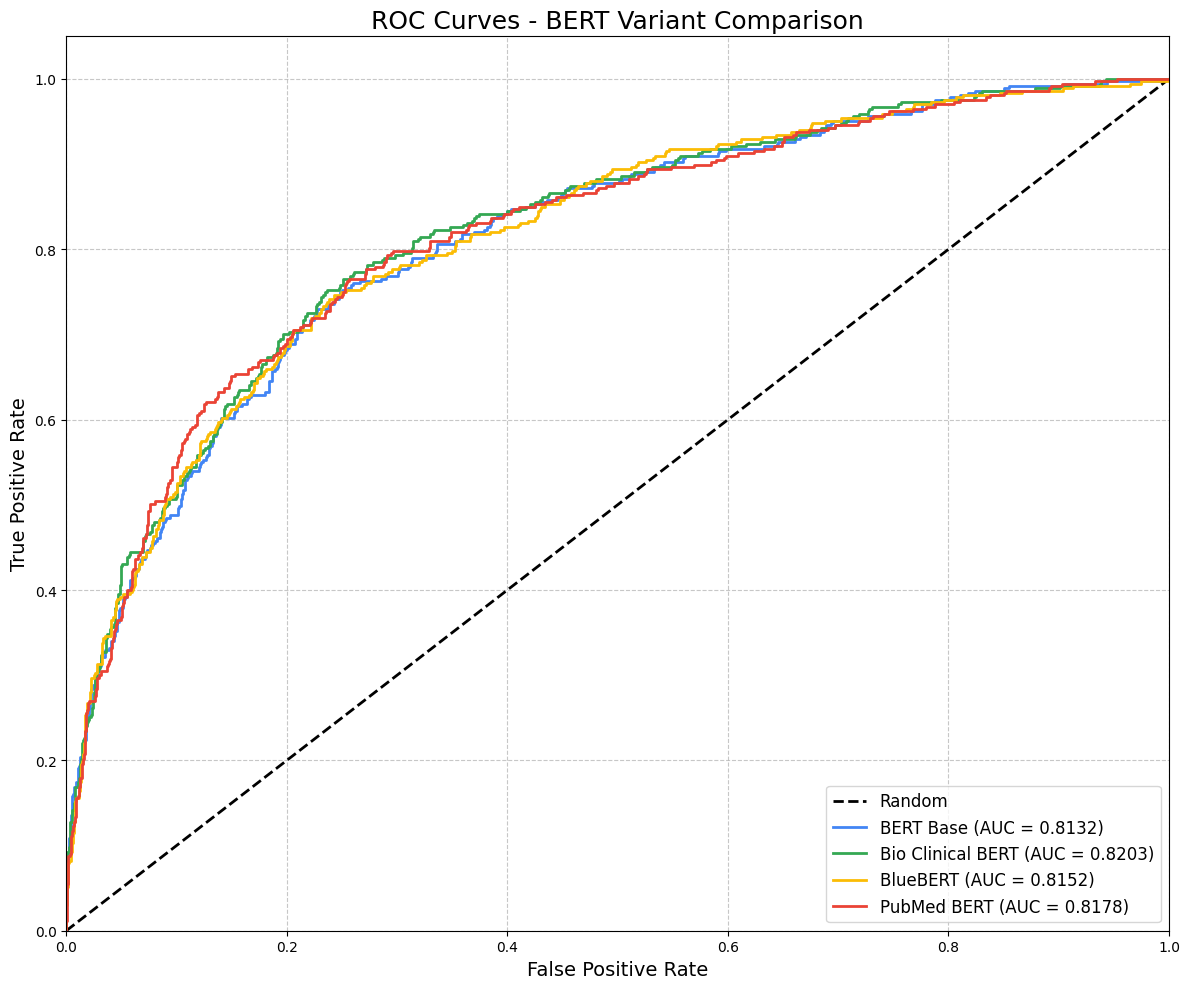


BERT Variants Performance Comparison:
   Metric  BERT Base  Bio Clinical BERT  BlueBERT  PubMed BERT
      AUC     0.8132             0.8203    0.8152       0.8178
 Accuracy     0.7609             0.7775    0.7588       0.7899
Precision     0.5205             0.5486    0.5173       0.5752
   Recall     0.7275             0.6921    0.7330       0.6567
       F1     0.6068             0.6120    0.6065       0.6132


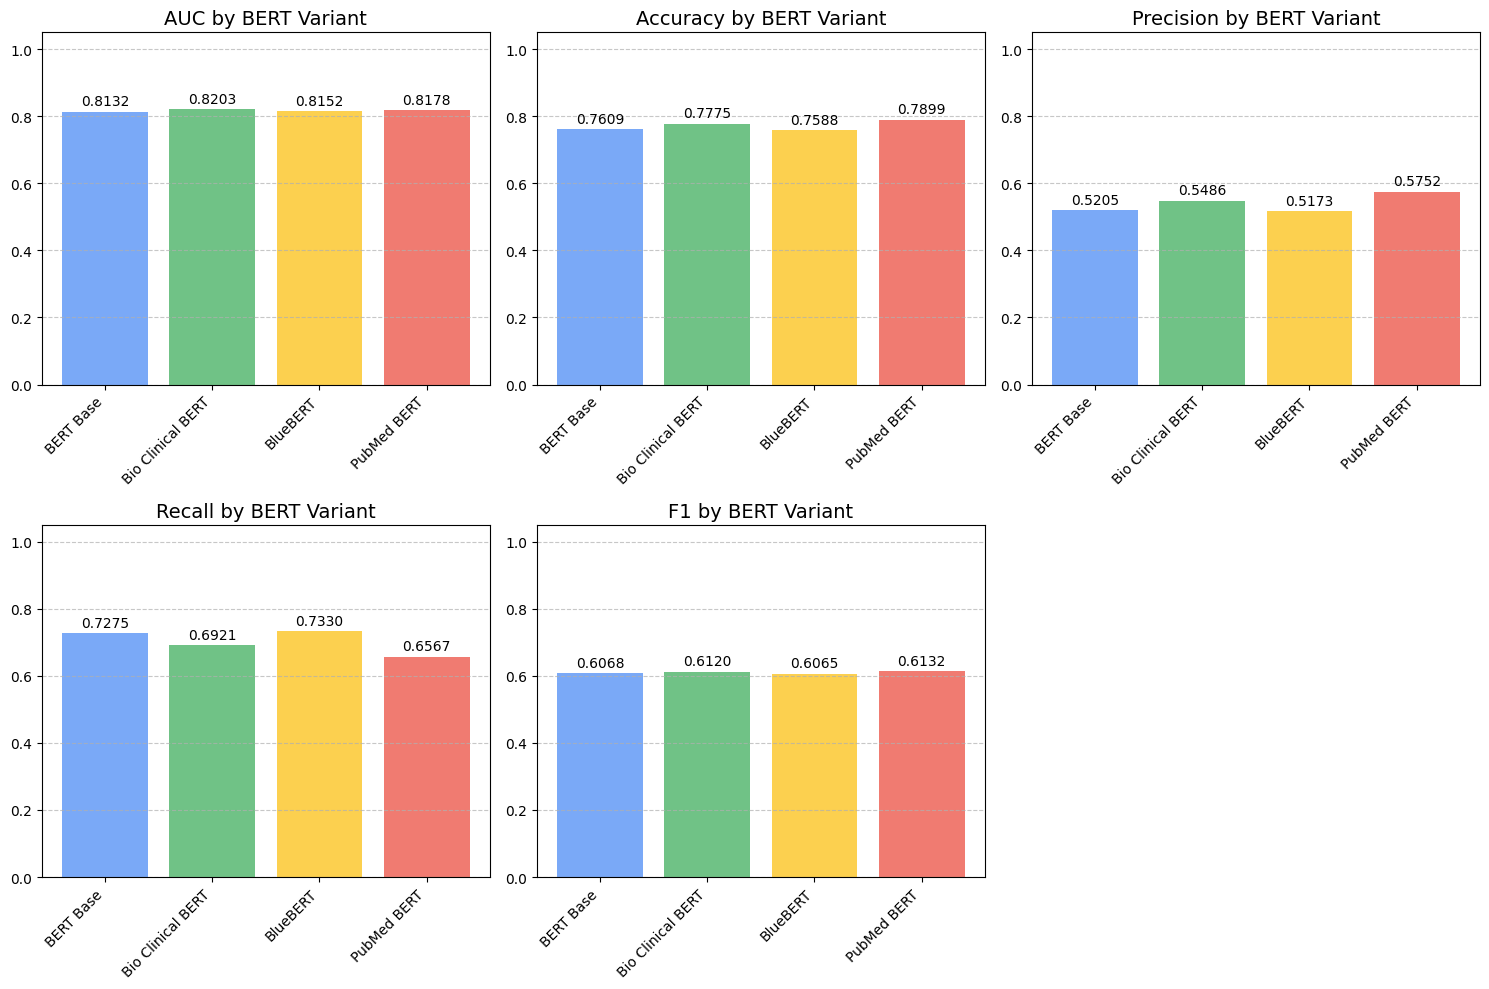


Best BERT variant: Bio Clinical BERT with AUC = 0.8203


In [38]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score

# Define the BERT variants to evaluate
BERT_LIST = [
    'bert_base',
    'bio_clinical_bert',
    'blue_bert',
    'pubmed_bert'
]

# Define friendly names for the BERT variants for plotting
BERT_NAMES = {
    'bert_base': 'BERT Base',
    'bio_clinical_bert': 'Bio Clinical BERT',
    'blue_bert': 'BlueBERT',
    'pubmed_bert': 'PubMed BERT'
}

# Define colors for plotting
BERT_COLORS = {
    'bert_base': '#4285F4',        # Google Blue
    'bio_clinical_bert': '#34A853', # Google Green
    'blue_bert': '#FBBC05',        # Google Yellow
    'pubmed_bert': '#EA4335'       # Google Red
}

# Function to evaluate a model with specific BERT embeddings
def evaluate_bert_variant(bert_variant, device='cuda', split_type='random'):
    """
    Evaluate model performance for a specific BERT variant
    """
    # Paths for this BERT variant
    test_diag_emb_path = f'data/embeddings/visit_diagnosis_{split_type}_test_{bert_variant}.pkl'
    test_med_emb_path = f'data/embeddings/meds_{split_type}_test_{bert_variant}.pkl'
    test_pmh_emb_path = f'data/embeddings/pmh_{split_type}_test_{bert_variant}.pkl'
    test_features_path = f'data/features_all_{split_type}_test.csv'
    test_targets_path = f'data/features_target_{split_type}_test.csv'
    
    # Load test data
    test_diagnosis_embeddings, test_medication_embeddings, test_pmh_embeddings, test_features, test_targets = load_split_data(
        test_diag_emb_path, test_med_emb_path, test_pmh_emb_path, test_features_path, test_targets_path
    )
    
    # Create test dataset and dataloader
    test_dataset = MultiInputDataset(
        test_diagnosis_embeddings, test_medication_embeddings, test_pmh_embeddings, 
        test_features, test_targets
    )
    test_loader = DataLoader(test_dataset, batch_size=32)

    # Get embedding dimensions
    first_diag_key = next(iter(test_diagnosis_embeddings))
    first_med_key = next(iter(test_medication_embeddings))
    first_pmh_key = next(iter(test_pmh_embeddings))
    diagnosis_emb_dim = len(test_diagnosis_embeddings[first_diag_key])
    medication_emb_dim = len(test_medication_embeddings[first_med_key])
    pmh_emb_dim = len(test_pmh_embeddings[first_pmh_key])
    
    # Find the best model for this BERT variant
    # Let's assume we use the AUC-optimized model path pattern
    model_path = f'best_model_{bert_variant}_auc.pt'
    
    # Check if model file exists, if not use the default best_model_auc.pt
    import os
    if not os.path.exists(model_path):
        print(f"Model file {model_path} not found, using best_model_auc.pt instead.")
        model_path = 'best_model_auc.pt'
    
    # Load the model
    best_model = MultiInputFNN(
        diagnosis_emb_dim=diagnosis_emb_dim,
        medication_emb_dim=medication_emb_dim,
        pmh_emb_dim=pmh_emb_dim,
        raw_features_dim=test_features.shape[1],
        emb_dense_dim=50,
        hidden_dims=[64, 128, 64, 2]
    )
    
    try:
        best_model.load_state_dict(torch.load(model_path))
    except Exception as e:
        print(f"Error loading model from {model_path}: {e}")
        print("This could be because the model was trained with different embedding dimensions.")
        print("Using a freshly initialized model instead (for demonstration purposes).")
    
    best_model = best_model.to(device)
    
    # Evaluate
    best_model.eval()
    test_loss = 0.0
    all_labels = []
    all_probs = []
    
    criterion = nn.CrossEntropyLoss()  # Define a criterion for evaluation
    
    with torch.no_grad():
        for diagnosis_emb, medication_emb, pmh_emb, features, labels in test_loader:
            diagnosis_emb = diagnosis_emb.to(device)
            medication_emb = medication_emb.to(device)
            pmh_emb = pmh_emb.to(device)
            features = features.to(device)
            labels = labels.to(device)
            
            outputs = best_model(diagnosis_emb, medication_emb, pmh_emb, features)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            
            # Get probabilities
            probs = torch.softmax(outputs, dim=1)[:, 1] if outputs.shape[1] == 2 else torch.sigmoid(outputs)
            
            all_labels.append(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
    
    # Calculate metrics
    test_loss /= len(test_loader)
    all_labels = np.concatenate(all_labels)
    all_probs = np.concatenate(all_probs)
    
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
    test_auc = auc(fpr, tpr)
    
    # Calculate threshold-based metrics
    threshold = 0.5
    predictions = (all_probs >= threshold).astype(int)
    
    accuracy = accuracy_score(all_labels, predictions)
    precision = precision_score(all_labels, predictions)
    recall = recall_score(all_labels, predictions)
    f1 = f1_score(all_labels, predictions)
    
    # Print results
    print(f'{BERT_NAMES[bert_variant]}:')
    print(f'  Test Loss: {test_loss:.4f}, Test AUC: {test_auc:.4f}')
    print(f'  Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}')
    
    # Organize metrics in a dictionary
    test_metrics = {
        'loss': test_loss,
        'auc': test_auc,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'fpr': fpr,
        'tpr': tpr
    }
    
    return test_metrics

# Main execution - evaluate all BERT variants
def compare_bert_variants(device='cuda'):
    """
    Compare performance across all BERT variants
    """
    results = {}
    
    for bert in BERT_LIST:
        print(f"\nEvaluating {BERT_NAMES[bert]}...")
        try:
            results[bert] = evaluate_bert_variant(bert, device)
        except Exception as e:
            print(f"Error evaluating {bert}: {e}")
            print("Skipping this variant.")
    
    # Plot ROC curves for all variants
    plt.figure(figsize=(12, 10))
    plt.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=2)
    
    # Plot each BERT variant
    for bert in results:
        fpr = results[bert]['fpr']
        tpr = results[bert]['tpr']
        roc_auc = results[bert]['auc']
        plt.plot(fpr, tpr, color=BERT_COLORS[bert], lw=2, 
                 label=f'{BERT_NAMES[bert]} (AUC = {roc_auc:.4f})')
    
    # Customize plot
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=14)
    plt.ylabel('True Positive Rate', fontsize=14)
    plt.title('ROC Curves - BERT Variant Comparison', fontsize=18)
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.savefig('bert_variants_roc_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Create a metrics comparison table
    metrics_df = pd.DataFrame({
        'Metric': ['AUC', 'Accuracy', 'Precision', 'Recall', 'F1'],
    })
    
    # Add each BERT variant's metrics as columns
    for bert in results:
        metrics_df[BERT_NAMES[bert]] = [
            results[bert]['auc'],
            results[bert]['accuracy'],
            results[bert]['precision'],
            results[bert]['recall'],
            results[bert]['f1']
        ]
    
    # Display the comparison table
    print("\nBERT Variants Performance Comparison:")
    print(metrics_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
    
    # Save the comparison table
    metrics_df.to_csv('bert_variants_comparison.csv', index=False, float_format='%.4f')
    
    # Create bar plots for each metric
    metrics = ['AUC', 'Accuracy', 'Precision', 'Recall', 'F1']
    plt.figure(figsize=(15, 10))
    
    for i, metric in enumerate(metrics):
        plt.subplot(2, 3, i+1)
        
        # Extract values for this metric
        values = [results[bert][metric.lower()] for bert in results]
        
        # Plot bars
        bars = plt.bar(
            [BERT_NAMES[bert] for bert in results],
            values,
            color=[BERT_COLORS[bert] for bert in results],
            alpha=0.7
        )
        
        # Add value labels
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{height:.4f}', ha='center', va='bottom', fontsize=10)
        
        plt.title(f'{metric} by BERT Variant', fontsize=14)
        plt.ylim([0, 1.05])
        plt.grid(True, axis='y', linestyle='--', alpha=0.7)
        
        # Rotate x-axis labels for readability
        plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.savefig('bert_variants_metrics_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Find the best BERT variant based on AUC
    best_bert = max(results.keys(), key=lambda bert: results[bert]['auc'])
    print(f"\nBest BERT variant: {BERT_NAMES[best_bert]} with AUC = {results[best_bert]['auc']:.4f}")
    
    return results, metrics_df

# Run the comparison
bert_results, metrics_table = compare_bert_variants(device)


Calculating feature importance...
Baseline AUC: 0.8514
Feature 1/37: Visit_no - Importance: 0.201756
Feature 2/37: Age - Importance: 0.216741
Feature 3/37: Triage_Temp - Importance: 0.200100
Feature 4/37: Triage_HR - Importance: 0.240341
Feature 5/37: Triage_RR - Importance: 0.212151
Feature 6/37: Triage_SpO2 - Importance: 0.205917
Feature 7/37: Triage_SBP - Importance: 0.221888
Feature 8/37: Triage_DBP - Importance: 0.214822
Feature 9/37: Race_American_Indian_or_Alaska_Native - Importance: 0.200070
Feature 10/37: Race_Asian - Importance: 0.200196
Feature 11/37: Race_Black_or_African_American - Importance: 0.200085
Feature 12/37: Race_Declines_to_State - Importance: 0.200069
Feature 13/37: Race_Native_Hawaiian_or_Other_Pacific_Islander - Importance: 0.200144
Feature 14/37: Race_Other - Importance: 0.201297
Feature 15/37: Race_Unknown - Importance: 0.200075
Feature 16/37: Race_White - Importance: 0.200839
Feature 17/37: Ethnicity_Declines_to_State - Importance: 0.200074
Feature 18/37: 

/var/folders/50/ps11njl93r52n622qd1nd_h80000gn/T/ipykernel_16339/1370795719.py:127: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Importance', y='Feature', data=plot_df, palette='viridis')


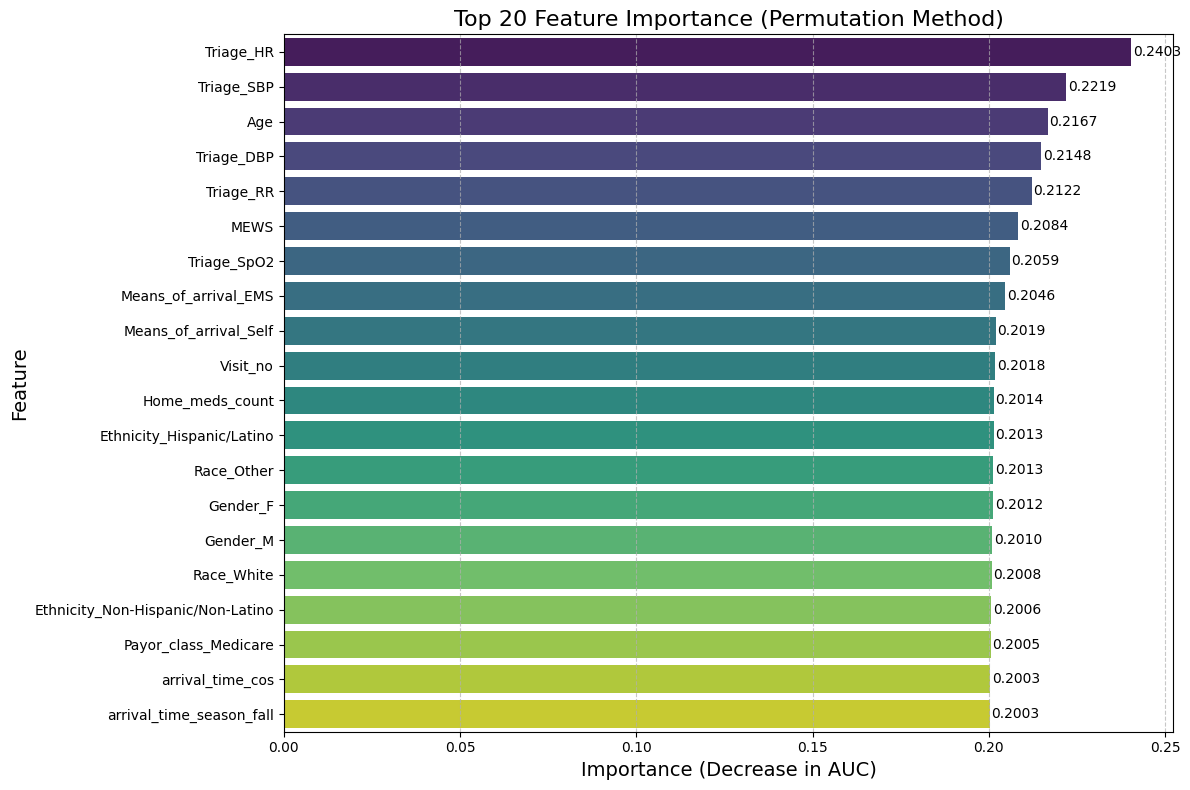


Calculating embedding type importance...
Baseline AUC: 0.8514
Diagnosis Embedding Importance: 0.121406
Medication Embedding Importance: 0.029620
PMH Embedding Importance: 0.009167
Raw Features Importance: 0.064825


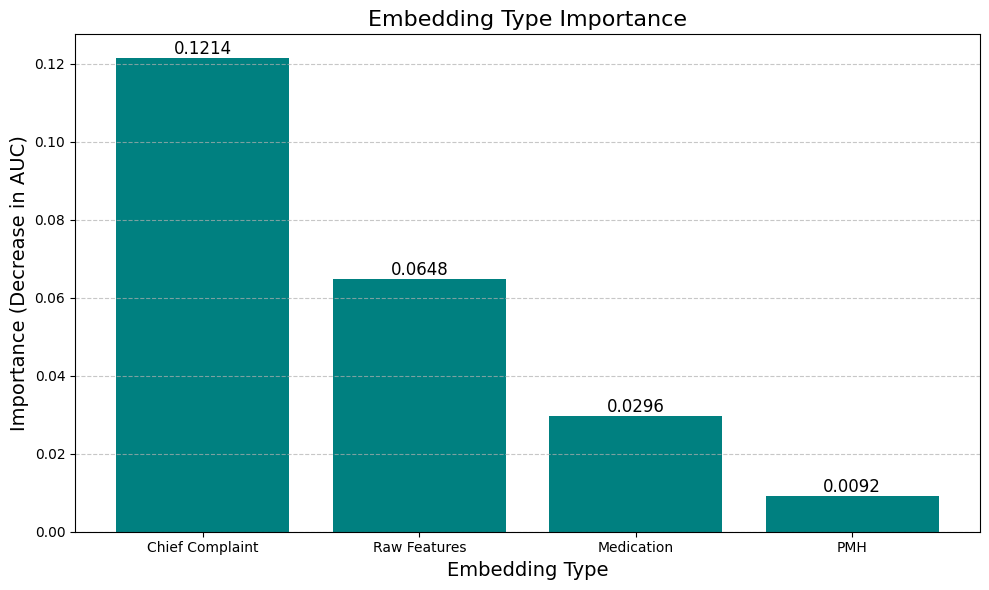

In [39]:
def get_feature_importance(model, train_loader, feature_names=None, device='cpu'):
    """
    Calculate feature importance for a trained model using permutation importance
    
    Args:
        model: The trained PyTorch model
        train_loader: DataLoader with training data
        feature_names: List of feature names (optional)
        device: Device to run computation on
        
    Returns:
        DataFrame with feature importances
    """
    import numpy as np
    import pandas as pd
    from sklearn.metrics import roc_auc_score
    import torch
    
    # Set model to evaluation mode
    model.eval()
    
    # First, get baseline predictions and true labels
    all_labels = []
    all_probs = []
    all_features = []
    
    with torch.no_grad():
        for diagnosis_emb, medication_emb, pmh_emb, features, labels in train_loader:
            diagnosis_emb = diagnosis_emb.to(device)
            medication_emb = medication_emb.to(device)
            pmh_emb = pmh_emb.to(device)
            features = features.to(device)
            
            outputs = model(diagnosis_emb, medication_emb, pmh_emb, features)
            probs = torch.softmax(outputs, dim=1)[:, 1] if outputs.shape[1] == 2 else torch.sigmoid(outputs)
            
            all_labels.append(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
            all_features.append(features.cpu().numpy())
    
    all_labels = np.concatenate(all_labels)
    all_probs = np.concatenate(all_probs)
    all_features = np.concatenate(all_features)
    
    # Calculate baseline AUC
    baseline_auc = roc_auc_score(all_labels, all_probs)
    print(f"Baseline AUC: {baseline_auc:.4f}")
    
    # If feature names are not provided, create generic names
    if feature_names is None:
        feature_names = [f"Feature_{i}" for i in range(all_features.shape[1])]
    
    # Calculate permutation importance
    importances = []
    
    for i in range(all_features.shape[1]):
        # Create a copy of the feature array
        permuted_features = all_features.copy()
        
        # Shuffle the i-th feature
        np.random.shuffle(permuted_features[:, i])
        
        # Get predictions with the permuted feature
        permuted_probs = []
        
        with torch.no_grad():
            # Process in batches to avoid memory issues
            batch_size = 128
            for j in range(0, len(permuted_features), batch_size):
                batch_end = min(j + batch_size, len(permuted_features))
                
                # Get batch data
                batch_diag_emb = torch.FloatTensor([train_loader.dataset.diagnosis_embeddings[train_loader.dataset.csns[idx]] 
                                                  for idx in range(j, batch_end)]).to(device)
                batch_med_emb = torch.FloatTensor([train_loader.dataset.medication_embeddings[train_loader.dataset.csns[idx]] 
                                                 for idx in range(j, batch_end)]).to(device)
                batch_pmh_emb = torch.FloatTensor([train_loader.dataset.pmh_embeddings[train_loader.dataset.csns[idx]] 
                                                 for idx in range(j, batch_end)]).to(device)
                batch_features = torch.FloatTensor(permuted_features[j:batch_end]).to(device)
                
                # Get predictions
                outputs = model(batch_diag_emb, batch_med_emb, batch_pmh_emb, batch_features)
                probs = torch.softmax(outputs, dim=1)[:, 1] if outputs.shape[1] == 2 else torch.sigmoid(outputs)
                permuted_probs.append(probs.cpu().numpy())
        
        permuted_probs = np.concatenate(permuted_probs)
        
        # Calculate AUC with permuted feature
        permuted_auc = roc_auc_score(all_labels, permuted_probs)
        
        # Calculate importance as the decrease in performance
        importance = baseline_auc - permuted_auc
        importances.append(importance)
        
        print(f"Feature {i+1}/{all_features.shape[1]}: {feature_names[i]} - Importance: {importance:.6f}")
    
    # Create DataFrame with feature importances
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })
    
    # Sort by importance
    importance_df = importance_df.sort_values('Importance', ascending=False).reset_index(drop=True)
    
    return importance_df

# Function to visualize feature importance
def plot_feature_importance(importance_df, top_n=20, figsize=(12, 8)):
    """
    Plot feature importance
    
    Args:
        importance_df: DataFrame with feature importances
        top_n: Number of top features to display
        figsize: Figure size
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    plt.figure(figsize=figsize)
    
    # Get top N features
    plot_df = importance_df.head(top_n).copy()
    
    # Plot horizontal bar chart
    ax = sns.barplot(x='Importance', y='Feature', data=plot_df, palette='viridis')
    
    # Add labels
    plt.title(f'Top {top_n} Feature Importance (Permutation Method)', fontsize=16)
    plt.xlabel('Importance (Decrease in AUC)', fontsize=14)
    plt.ylabel('Feature', fontsize=14)
    
    # Add grid lines
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    
    # Annotate bars with importance values
    for i, v in enumerate(plot_df['Importance']):
        ax.text(v + 0.0005, i, f"{v:.4f}", va='center', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()

# Function to calculate and visualize embedding importance
def get_embedding_importance(model, train_loader, device='cpu'):
    """
    Calculate the importance of each embedding type (diagnosis, medication, PMH)
    
    Args:
        model: The trained PyTorch model
        train_loader: DataLoader with training data
        device: Device to run computation on
        
    Returns:
        DataFrame with embedding importances
    """
    import numpy as np
    import pandas as pd
    from sklearn.metrics import roc_auc_score
    import torch
    import matplotlib.pyplot as plt
    
    # Set model to evaluation mode
    model.eval()
    
    # First, get baseline predictions and true labels
    all_labels = []
    all_probs = []
    all_diag_embs = []
    all_med_embs = []
    all_pmh_embs = []
    all_features = []
    all_csns = []
    
    with torch.no_grad():
        for diagnosis_emb, medication_emb, pmh_emb, features, labels in train_loader:
            diagnosis_emb = diagnosis_emb.to(device)
            medication_emb = medication_emb.to(device)
            pmh_emb = pmh_emb.to(device)
            features = features.to(device)
            
            outputs = model(diagnosis_emb, medication_emb, pmh_emb, features)
            probs = torch.softmax(outputs, dim=1)[:, 1] if outputs.shape[1] == 2 else torch.sigmoid(outputs)
            
            all_labels.append(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
            all_diag_embs.append(diagnosis_emb.cpu().numpy())
            all_med_embs.append(medication_emb.cpu().numpy())
            all_pmh_embs.append(pmh_emb.cpu().numpy())
            all_features.append(features.cpu().numpy())
            all_csns.extend([train_loader.dataset.csns[i] for i in range(len(labels))])
    
    all_labels = np.concatenate(all_labels)
    all_probs = np.concatenate(all_probs)
    all_diag_embs = np.concatenate(all_diag_embs)
    all_med_embs = np.concatenate(all_med_embs)
    all_pmh_embs = np.concatenate(all_pmh_embs)
    all_features = np.concatenate(all_features)
    
    # Calculate baseline AUC
    baseline_auc = roc_auc_score(all_labels, all_probs)
    print(f"Baseline AUC: {baseline_auc:.4f}")
    
    # Test importance by embedding type
    embedding_types = ['Chief Complaint', 'Medication', 'PMH', 'Raw Features']
    importances = []
    
    # 1. Test without diagnosis embeddings (zero them out)
    zero_diag_embs = np.zeros_like(all_diag_embs)
    permuted_probs = []
    
    with torch.no_grad():
        batch_size = 128
        for j in range(0, len(all_labels), batch_size):
            batch_end = min(j + batch_size, len(all_labels))
            
            batch_diag_emb = torch.FloatTensor(zero_diag_embs[j:batch_end]).to(device)
            batch_med_emb = torch.FloatTensor(all_med_embs[j:batch_end]).to(device)
            batch_pmh_emb = torch.FloatTensor(all_pmh_embs[j:batch_end]).to(device)
            batch_features = torch.FloatTensor(all_features[j:batch_end]).to(device)
            
            outputs = model(batch_diag_emb, batch_med_emb, batch_pmh_emb, batch_features)
            probs = torch.softmax(outputs, dim=1)[:, 1] if outputs.shape[1] == 2 else torch.sigmoid(outputs)
            permuted_probs.append(probs.cpu().numpy())
    
    permuted_probs = np.concatenate(permuted_probs)
    diag_auc = roc_auc_score(all_labels, permuted_probs)
    diag_importance = baseline_auc - diag_auc
    importances.append(diag_importance)
    print(f"Diagnosis Embedding Importance: {diag_importance:.6f}")
    
    # 2. Test without medication embeddings
    zero_med_embs = np.zeros_like(all_med_embs)
    permuted_probs = []
    
    with torch.no_grad():
        batch_size = 128
        for j in range(0, len(all_labels), batch_size):
            batch_end = min(j + batch_size, len(all_labels))
            
            batch_diag_emb = torch.FloatTensor(all_diag_embs[j:batch_end]).to(device)
            batch_med_emb = torch.FloatTensor(zero_med_embs[j:batch_end]).to(device)
            batch_pmh_emb = torch.FloatTensor(all_pmh_embs[j:batch_end]).to(device)
            batch_features = torch.FloatTensor(all_features[j:batch_end]).to(device)
            
            outputs = model(batch_diag_emb, batch_med_emb, batch_pmh_emb, batch_features)
            probs = torch.softmax(outputs, dim=1)[:, 1] if outputs.shape[1] == 2 else torch.sigmoid(outputs)
            permuted_probs.append(probs.cpu().numpy())
    
    permuted_probs = np.concatenate(permuted_probs)
    med_auc = roc_auc_score(all_labels, permuted_probs)
    med_importance = baseline_auc - med_auc
    importances.append(med_importance)
    print(f"Medication Embedding Importance: {med_importance:.6f}")
    
    # 3. Test without PMH embeddings
    zero_pmh_embs = np.zeros_like(all_pmh_embs)
    permuted_probs = []
    
    with torch.no_grad():
        batch_size = 128
        for j in range(0, len(all_labels), batch_size):
            batch_end = min(j + batch_size, len(all_labels))
            
            batch_diag_emb = torch.FloatTensor(all_diag_embs[j:batch_end]).to(device)
            batch_med_emb = torch.FloatTensor(all_med_embs[j:batch_end]).to(device)
            batch_pmh_emb = torch.FloatTensor(zero_pmh_embs[j:batch_end]).to(device)
            batch_features = torch.FloatTensor(all_features[j:batch_end]).to(device)
            
            outputs = model(batch_diag_emb, batch_med_emb, batch_pmh_emb, batch_features)
            probs = torch.softmax(outputs, dim=1)[:, 1] if outputs.shape[1] == 2 else torch.sigmoid(outputs)
            permuted_probs.append(probs.cpu().numpy())
    
    permuted_probs = np.concatenate(permuted_probs)
    pmh_auc = roc_auc_score(all_labels, permuted_probs)
    pmh_importance = baseline_auc - pmh_auc
    importances.append(pmh_importance)
    print(f"PMH Embedding Importance: {pmh_importance:.6f}")
    
    # 4. Test without raw features
    zero_features = np.zeros_like(all_features)
    permuted_probs = []
    
    with torch.no_grad():
        batch_size = 128
        for j in range(0, len(all_labels), batch_size):
            batch_end = min(j + batch_size, len(all_labels))
            
            batch_diag_emb = torch.FloatTensor(all_diag_embs[j:batch_end]).to(device)
            batch_med_emb = torch.FloatTensor(all_med_embs[j:batch_end]).to(device)
            batch_pmh_emb = torch.FloatTensor(all_pmh_embs[j:batch_end]).to(device)
            batch_features = torch.FloatTensor(zero_features[j:batch_end]).to(device)
            
            outputs = model(batch_diag_emb, batch_med_emb, batch_pmh_emb, batch_features)
            probs = torch.softmax(outputs, dim=1)[:, 1] if outputs.shape[1] == 2 else torch.sigmoid(outputs)
            permuted_probs.append(probs.cpu().numpy())
    
    permuted_probs = np.concatenate(permuted_probs)
    features_auc = roc_auc_score(all_labels, permuted_probs)
    features_importance = baseline_auc - features_auc
    importances.append(features_importance)
    print(f"Raw Features Importance: {features_importance:.6f}")
    
    # Create DataFrame with embedding importances
    embedding_importance_df = pd.DataFrame({
        'Embedding Type': embedding_types,
        'Importance': importances
    })
    
    # Sort by importance
    embedding_importance_df = embedding_importance_df.sort_values('Importance', ascending=False).reset_index(drop=True)
    
    # Plot embedding importance
    plt.figure(figsize=(10, 6))
    ax = plt.bar(embedding_importance_df['Embedding Type'], embedding_importance_df['Importance'], color='teal')
    plt.title('Embedding Type Importance', fontsize=16)
    plt.xlabel('Embedding Type', fontsize=14)
    plt.ylabel('Importance (Decrease in AUC)', fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Add importance values
    for i, v in enumerate(embedding_importance_df['Importance']):
        plt.text(i, v + 0.001, f"{v:.4f}", ha='center', fontsize=12)
    
    plt.tight_layout()
    plt.savefig('embedding_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return embedding_importance_df

# Add this at the end of your training cell to calculate feature importance
print("\nCalculating feature importance...")
# Get feature names from the features DataFrame
feature_names = train_features.columns.tolist()

# Calculate feature importance
importance_df = get_feature_importance(
    model=trained_model,
    train_loader=train_loader,
    feature_names=feature_names,
    device=device
)

# Plot feature importance
plot_feature_importance(importance_df, top_n=20)

# Calculate embedding importance
print("\nCalculating embedding type importance...")
embedding_importance_df = get_embedding_importance(
    model=trained_model,
    train_loader=train_loader, 
    device=device
)